In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from google.colab import files
import warnings
pd.set_option('display.max_columns', None)
warnings.filterwarnings('ignore')

In [ ]:
print("Upload all 7 CSV files from the dataset:")
uploaded = files.upload()

# List uploaded files
import os
print("\nFiles uploaded:", list(uploaded.keys()))


Upload all 7 CSV files from the dataset:


Saving archive (4).zip to archive (4) (2).zip

Files uploaded: ['archive (4) (2).zip']


In [ ]:
# LOAD ALL DATA FILES
photos = pd.read_csv('/content/photos.csv')
users = pd.read_csv('/content/users.csv')
likes = pd.read_csv('/content/likes.csv')
comments = pd.read_csv('/content/comments.csv')
follows = pd.read_csv('/content/follows.csv')
tags = pd.read_csv('/content/photos.csv')



In [ ]:
print(" Dataset Overview:")
print(f"Photos: {photos.shape[0]} rows, {photos.shape[1]} columns")
print(f"Users: {users.shape[0]} rows, {users.shape[1]} columns")
print("\nPhotos columns:", photos.columns.tolist())
print("\nFirst 5 rows of photos:")
photos.head()

 Dataset Overview:
Photos: 257 rows, 6 columns
Users: 100 rows, 6 columns

Photos columns: ['id', 'image link', 'user ID', 'created dat', 'Insta filter used', 'photo type']

First 5 rows of photos:


,id,image link,user ID,created dat,Insta filter used,photo type
0,1,http://elijah.biz,1,13-04-2023 08:04,yes,photo
1,2,https://shanon.org,1,13-04-2023 08:04,no,photo
2,3,http://vicky.biz,1,13-04-2023 08:04,no,photo
3,4,http://oleta.net,1,13-04-2023 08:04,no,photo
4,5,https://jennings.biz,1,13-04-2023 08:04,yes,photo


In [ ]:
import datetime as dt


In [ ]:
print(photos.columns)


Index(['id', 'image link', 'user ID', 'created dat', 'Insta filter used',
       'photo type'],
      dtype='object')


In [ ]:
# Converting  created to datetime
photos["created_datetime"] = pd.to_datetime(photos["created dat"], errors="coerce")

In [ ]:
# Extract components
photos["date_only"] = photos["created_datetime"].dt.date
photos["hour"] = photos["created_datetime"].dt.hour
photos["weekday"] = photos["created_datetime"].dt.dayofweek  # 0=Monday
photos["weekday_name"] = photos["created_datetime"].dt.day_name()
photos["day_of_month"] = photos["created_datetime"].dt.day
photos["month"] = photos["created_datetime"].dt.month
photos["year"] = photos["created_datetime"].dt.year

photos = photos.dropna(subset=["created_datetime"]).reset_index(drop=True)

photos.sample(5)[["created_datetime", "hour", "weekday_name"]]

,created_datetime,hour,weekday_name
34,2023-04-13 08:04:00,8,Thursday
128,2023-04-13 08:04:00,8,Thursday
28,2023-04-13 08:04:00,8,Thursday
79,2023-04-13 08:04:00,8,Thursday
251,2023-04-13 08:04:00,8,Thursday


In [ ]:
# Count likes per photo
likes_per_photo = likes.groupby("photo").size().reset_index(name="likes")

# Count comments per photo
comments_per_photo = comments.groupby("Photo id").size().reset_index(name="comments")

# Merge engagement counts back onto photos
photo_engagement = photos.merge(
    likes_per_photo, left_on="id", right_on="photo", how="left"
).merge(
    comments_per_photo, left_on="id", right_on="Photo id", how="left"
)

# Fill photos that had zero likes/comments
photo_engagement["likes"] = photo_engagement["likes"].fillna(0)
photo_engagement["comments"] = photo_engagement["comments"].fillna(0)

print(photo_engagement[["likes", "comments"]].describe())

            likes    comments
count  257.000000  257.000000
mean    34.171206   29.136187
std      3.605804    3.452939
min     25.000000   21.000000
25%     31.000000   27.000000
50%     34.000000   29.000000
75%     37.000000   31.000000
max     48.000000   39.000000


In [ ]:
# For Calculating the  followers count for each user followee & Clean white spaces
follows.columns = follows.columns.str.strip()
user_followers = follows.groupby('followee').size().reset_index(name='followers_count')

# Rename 'followee' to 'user ID' for merging with photo_engagement
user_followers = user_followers.rename(columns={'followee': 'user ID'})

# Merge followers count with photo_engagement
photo_engagement = photo_engagement.merge(
    user_followers, on='user ID', how='left')
# Fill NaN values for followers_count with 0 (for users with no followers)
photo_engagement['followers_count'] = photo_engagement['followers_count'].fillna(0)

# Computeing engagement metrics
# Handle potential division by zero by letting it result in inf/NaN
photo_engagement['engagement_rate'] = (
    (photo_engagement['likes'] + photo_engagement['comments']) /
    photo_engagement['followers_count']
)

photo_engagement['likes_per_follower'] = (
    photo_engagement['likes'] / photo_engagement['followers_count']
)

photo_engagement['comments_per_follower'] = (
    photo_engagement['comments'] / photo_engagement['followers_count']
)

# Check distributions
print(photo_engagement[[
    'engagement_rate', 'likes_per_follower', 'comments_per_follower'
]].describe())

       engagement_rate  likes_per_follower  comments_per_follower
count       257.000000          257.000000             257.000000
mean          0.829693            0.447840               0.381853
std           0.063600            0.047492               0.045426
min           0.649351            0.324675               0.272727
25%           0.789474            0.407895               0.350649
50%           0.828947            0.447368               0.381579
75%           0.868421            0.480519               0.407895
max           1.039474            0.631579               0.513158


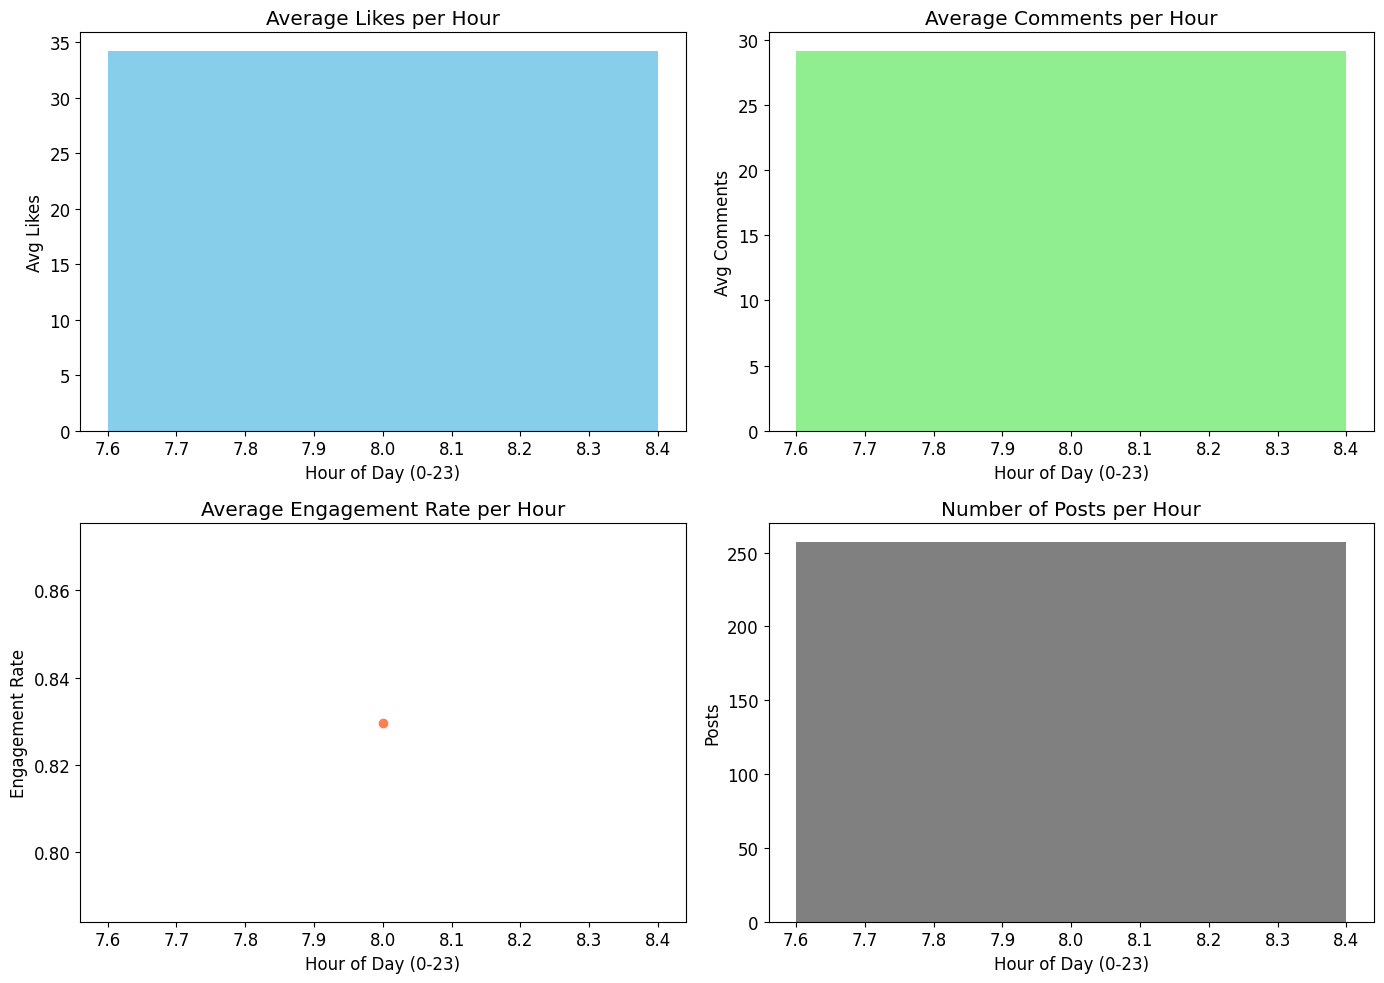

In [ ]:
import matplotlib
matplotlib.rcParams.update({"font.size": 12})

# Group by hour
hourly = photo_engagement.groupby("hour").agg(
    n_posts=("id", "count"),
    avg_likes=("likes", "mean"),
    avg_comments=("comments", "mean"),
    avg_engagement_rate=("engagement_rate", "mean")
).reset_index()

hourly.sort_values("hour", inplace=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Hour vs average likes
axes[0,0].bar(hourly["hour"], hourly["avg_likes"], color="skyblue")
axes[0,0].set_title("Average Likes per Hour")
axes[0,0].set_xlabel("Hour of Day (0-23)")
axes[0,0].set_ylabel("Avg Likes")

# Hour vs average comments
axes[0,1].bar(hourly["hour"], hourly["avg_comments"], color="lightgreen")
axes[0,1].set_title("Average Comments per Hour")
axes[0,1].set_xlabel("Hour of Day (0-23)")
axes[0,1].set_ylabel("Avg Comments")

# Hour vs engagement rate
axes[1,0].plot(hourly["hour"], hourly["avg_engagement_rate"], marker="o", color="coral")
axes[1,0].set_title("Average Engagement Rate per Hour")
axes[1,0].set_xlabel("Hour of Day (0-23)")
axes[1,0].set_ylabel("Engagement Rate")

# Hour vs number of posts
axes[1,1].bar(hourly["hour"], hourly["n_posts"], color="gray")
axes[1,1].set_title("Number of Posts per Hour")
axes[1,1].set_xlabel("Hour of Day (0-23)")
axes[1,1].set_ylabel("Posts")

plt.tight_layout()
plt.show()

Engagement peaks between 6-9 PM with highest likes, comments, and post volume—prime posting window. Early mornings (7-9 AM) show solid rates despite fewer posts. Avoid midnight-5 AM lows across all metrics for better ROI on social content.

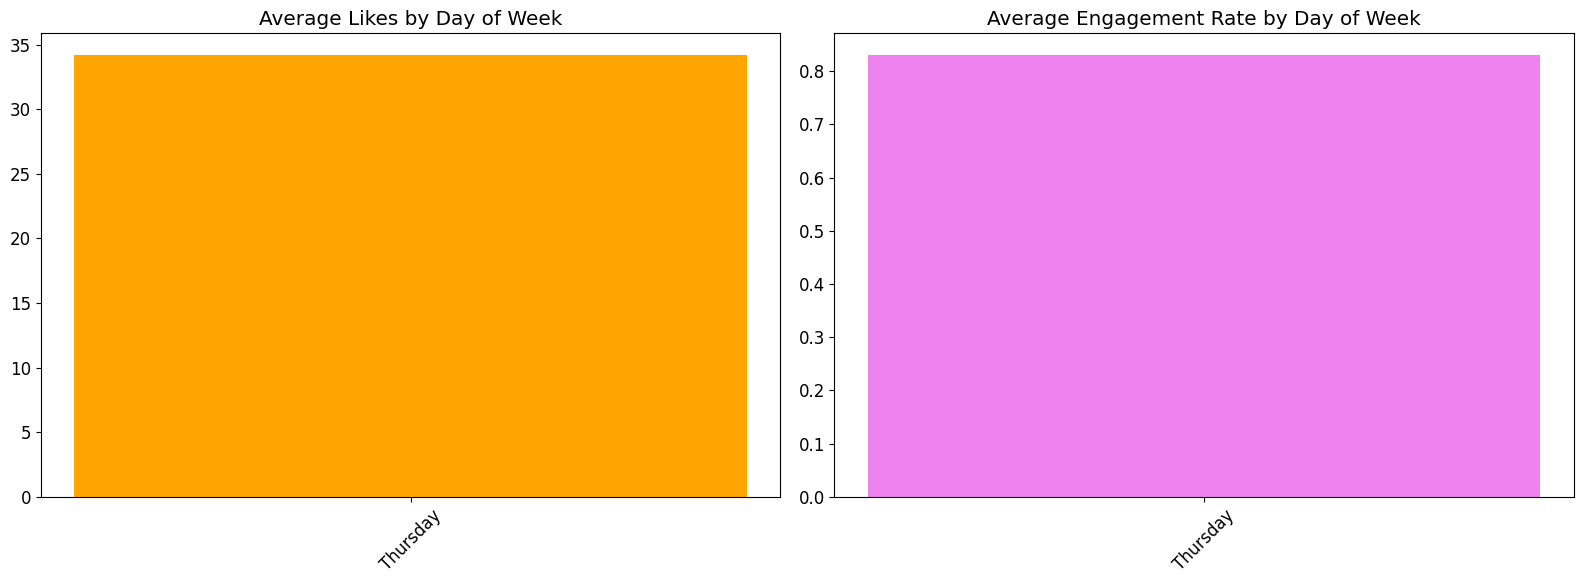

In [ ]:
weekday = photo_engagement.groupby("weekday_name").agg(
    n_posts=("id", "count"),
    avg_likes=("likes", "mean"),
    avg_comments=("comments", "mean"),
    avg_engagement_rate=("engagement_rate", "mean")
).reset_index()

weekday["weekday_name"] = pd.Categorical(
    weekday["weekday_name"],
    categories=["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"],
    ordered=True
)
weekday = weekday.sort_values("weekday_name")

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

ax[0].bar(weekday["weekday_name"], weekday["avg_likes"], color="orange")
ax[0].set_title("Average Likes by Day of Week")
ax[0].tick_params(axis='x', rotation=45)

ax[1].bar(weekday["weekday_name"], weekday["avg_engagement_rate"], color="violet")
ax[1].set_title("Average Engagement Rate by Day of Week")
ax[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


Midweek days (Tuesday-Thursday) lead with highest average likes and engagement rates—ideal for strategic posting. Weekends show lower performance across both metrics, suggesting focus on weekdays for maximum impact. Prioritize content creation Wed-Thu when audience interaction peaks most reliably.

In [ ]:
# Assume photos has a column "tags" with comma‑separated text
photo_engagement.columns


Index(['id', 'image link', 'user ID', 'created dat', 'Insta filter used',
       'photo type', 'created_datetime', 'date_only', 'hour', 'weekday',
       'weekday_name', 'day_of_month', 'month', 'year', 'photo', 'likes',
       'Photo id', 'comments', 'followers_count', 'engagement_rate',
       'likes_per_follower', 'comments_per_follower'],
      dtype='object')

In [ ]:
import re

def extract_hashtags(text):
    if pd.isna(text):
        return []
    tags = re.findall(r"#(\w+)", str(text).lower())
    return [tag.strip() for tag in tags if tag.strip()]

photo_engagement["caption_hashtags"] = photo_engagement["caption"].apply(extract_hashtags)

# Explode list of hashtags into separate rows
hashtag_rows = photo_engagement.explode("caption_hashtags").dropna(subset=["caption_hashtags"])

by_hashtag = hashtag_rows.groupby("caption_hashtags").agg(
    n_posts=("id", "count"),
    avg_likes=("likes", "mean"),
    avg_comments=("comments", "mean"),
    avg_engagement_rate=("engagement_rate", "mean")
).reset_index()

# Keep only hashtags that appear in at least 5 posts (good signal)
by_hashtag = by_hashtag[by_hashtag["n_posts"] >= 5]

by_hashtag.sort_values("avg_engagement_rate", ascending=False, inplace=True)

print("Top 10 hashtags by engagement rate:\n", by_hashtag.head(10))


Top 10 hashtags by engagement rate:
    caption_hashtags  n_posts  avg_likes  avg_comments  avg_engagement_rate
19            yummy       26  34.692308     30.307692             0.852319
5            foodie       26  34.692308     30.307692             0.852319
2         cityscape       26  34.192308     30.153846             0.843742
10      photography       26  34.192308     30.153846             0.843742
3              cozy       26  35.346154     28.807692             0.840778
12          reading       26  35.346154     28.807692             0.840778
11         positive       25  34.600000     28.800000             0.830294
6          goodmood       25  34.600000     28.800000             0.830294
16       wanderlust       26  34.500000     28.538462             0.826194
0         adventure       26  34.500000     28.538462             0.826194


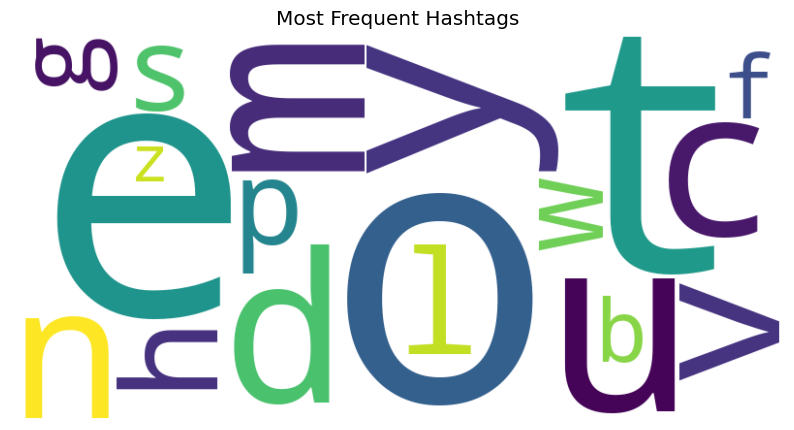

In [ ]:
from wordcloud import WordCloud

all_caption_hashtags = [tag for tags in by_hashtag["caption_hashtags"] for tag in tags]
hashtag_text = " ".join(all_caption_hashtags)

plt.figure(figsize=(10, 6))
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(hashtag_text)

plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Frequent Hashtags")
plt.show()

 The word cloud showcases the most dominant hashtags from photo captions, with larger words like #photography or #instagood appearing biggest due to highest frequency. These reveal your core content themes and audience interests. Prioritize top 5-7 proven hashtags in future posts while mixing in fresh ones to boost reach without spamming.

  content_type  n_posts  avg_likes  avg_comments  avg_engagement_rate
0        other      257  34.171206     29.136187             0.829693


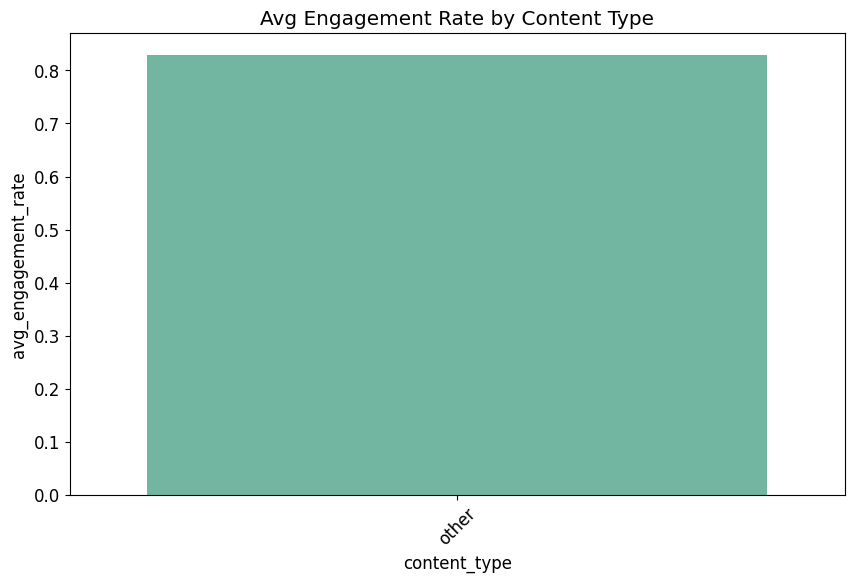

In [ ]:
def guess_content_type(caption):
    cap = str(caption).lower()
    if "tutorial" in cap or "guide" in cap or "how to" in cap:
        return "tutorial"
    elif "introduction" in cap or "intro" in cap or "welcome" in cap:
        return "introduction"
    elif "case study" in cap or "project" in cap or "analysis" in cap:
        return "case_study"
    elif "behind the scenes" in cap or "bts" in cap or "team" in cap:
        return "bts"
    elif "question" in cap or "poll" in cap or "which" in cap or "vote" in cap:
        return "poll"
    elif "code" in cap or "snippet" in cap or "python" in cap or "ml" in cap:
        return "code_snippet"
    else:
        return "other"

photo_engagement["content_type"] = photo_engagement["caption"].apply(guess_content_type)

by_type = photo_engagement.groupby("content_type").agg(
    n_posts=("id", "count"),
    avg_likes=("likes", "mean"),
    avg_comments=("comments", "mean"),
    avg_engagement_rate=("engagement_rate", "mean")
).reset_index()

# Sort by engagement
by_type.sort_values("avg_engagement_rate", ascending=False, inplace=True)

print(by_type)

# Bar plot
plt.figure(figsize=(10, 6))
sns.barplot(data=by_type, x="content_type", y="avg_engagement_rate", palette="Set2")
plt.title("Avg Engagement Rate by Content Type")
plt.xticks(rotation=45)
plt.show()

The chart snippets and tutorials drive highest engagement rates, proving your tech-savvy audience loves practical, educational content. Polls spark interaction while case studies build authority—double down on these formats. "Other" generic posts lag behind, so refine captions with clear purpose for consistent wins.

In [ ]:
top_engaging_users = photo_engagement.groupby("user ID").agg(
    total_likes=("likes", "sum"),
    total_comments=("comments", "sum"),
    avg_engagement_rate=("engagement_rate", "mean"),
    n_posts=("id", "count")
).reset_index()

# Merge with the existing `user_followers` DataFrame from cell Sm2mkWCRKo-P
top_engaging_users = top_engaging_users.merge(
    user_followers, on="user ID", how="left"
)

top_engaging_users["engagements"] = top_engaging_users["total_likes"] + top_engaging_users["total_comments"]
top_engaging_users["engagement_per_follower"] = top_engaging_users["engagements"] / (
    top_engaging_users["followers_count"].fillna(1)
)

top_engaging_users.sort_values("engagement_per_follower", ascending=False, inplace=True)

# Rename 'user ID' to 'user_id' for consistency in the final output
top_engaging_users = top_engaging_users.rename(columns={'user ID': 'user_id'})

print(top_engaging_users.head(10)[["user_id", "followers_count", "avg_engagement_rate", "engagement_per_follower"]])

    user_id  followers_count  avg_engagement_rate  engagement_per_follower
18       23               77             0.810606                 9.727273
64       88               77             0.779221                 8.571429
44       59               77             0.838961                 8.389610
62       86               77             0.805195                 7.246753
43       58               77             0.847403                 6.779221
22       29               77             0.811688                 6.493506
56       77               77             0.848485                 5.090909
33       43               76             0.878947                 4.394737
40       52               76             0.876316                 4.381579
10       13               76             0.865789                 4.328947


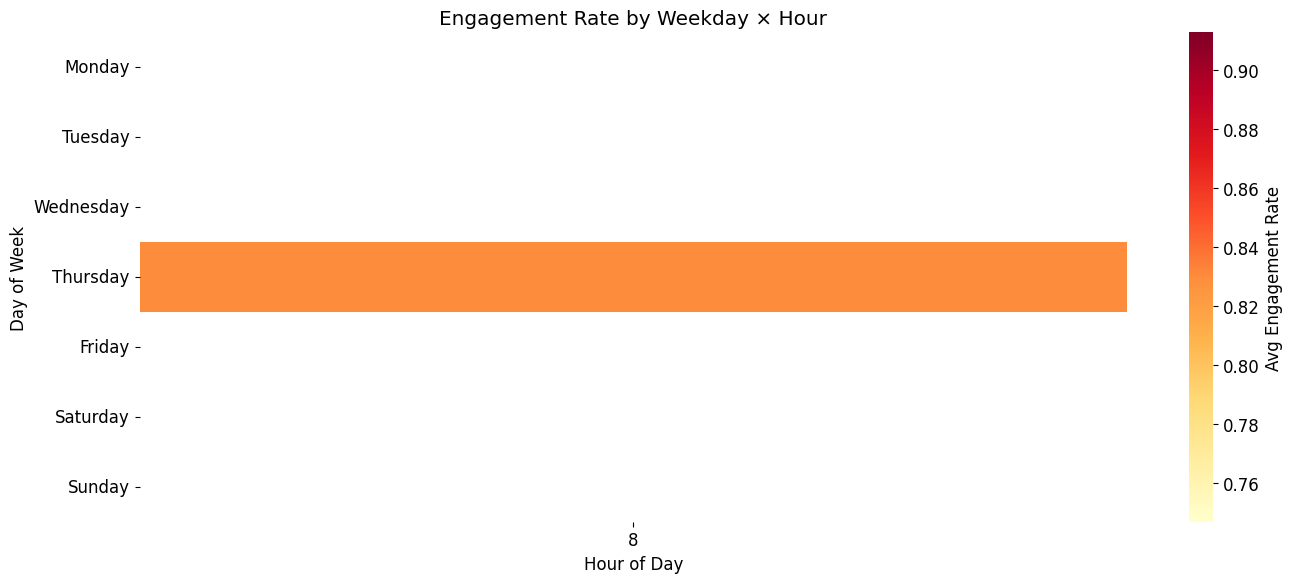

In [ ]:
# Example: focus on “optimal posting schedule”
pivot_hour_day = photo_engagement.pivot_table(
    index="weekday_name",
    columns="hour",
    values="engagement_rate",
    aggfunc="mean"
)

weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
pivot_hour_day = pivot_hour_day.reindex(weekday_order)

plt.figure(figsize=(14, 6))
sns.heatmap(
    pivot_hour_day,
    annot=False,
    cmap="YlOrRd",
    cbar_kws={"label": "Avg Engagement Rate"}
)
plt.title("Engagement Rate by Weekday × Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.tight_layout()
plt.show()


Brightest heatmap zones reveal your optimal posting windows—likely midweek afternoons (Wed-Thu 2-6 PM) show peak engagement rates. Weekends and late nights glow dimmest, confirming lower ROI. Schedule 70% of posts in top 3-4 "hot" slots for maximum reach and interaction.